### Получаем данные

In [1]:
from src.mlcore.dataloader import get_processed_data

raw = get_processed_data(
    source="raw",
    symbol="BTCUSDC",
    drop_last=True,
    save_dir="parquets/",
    grid_resolution_ms=5000,
)
raw

orderbook_snapshots: 100%|██████████| 4/4 [00:04<00:00,  1.09s/it]


,exchange_ts,open,high,low,close,volume,volume_1s,buy_volume_1s,sell_volume_1s,volume_imbalance_1s,...,ask_qty_90,ask_qty_91,ask_qty_92,ask_qty_93,ask_qty_94,ask_qty_95,ask_qty_96,ask_qty_97,ask_qty_98,ask_qty_99
0,2026-01-23 11:50:30,89139.500000,89139.500000,89130.500000,89130.500000,0.769,0.000,0.0,0.000,0.0,...,0.139,0.450,0.142,0.020,0.182,0.141,0.044,0.114,0.141,0.020
1,2026-01-23 11:50:35,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.196,0.0,0.196,-1.0,...,0.004,0.139,0.020,0.002,0.139,1.094,0.139,0.177,1.010,1.796
2,2026-01-23 11:50:40,89130.398438,89130.398438,89130.398438,89130.398438,0.002,0.000,0.0,0.000,0.0,...,1.094,0.139,1.122,1.796,0.139,1.002,0.112,1.307,0.179,0.142
3,2026-01-23 11:50:45,89130.398438,89130.398438,89128.000000,89128.101562,0.232,0.000,0.0,0.000,0.0,...,0.168,0.005,0.139,0.415,0.068,0.139,0.004,0.139,0.978,0.139
4,2026-01-23 11:50:50,89128.101562,89128.101562,89128.101562,89128.101562,0.002,0.004,0.0,0.004,-1.0,...,0.150,1.000,0.112,0.141,0.002,0.139,0.005,0.139,0.415,0.003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1972909,2026-05-17 15:59:35,77995.203125,77995.203125,77995.203125,77995.203125,0.017,0.001,0.0,0.001,-1.0,...,0.017,0.020,0.048,0.003,0.065,0.008,0.002,0.020,0.077,0.001
1972910,2026-05-17 15:59:40,77995.203125,77995.203125,77994.398438,77994.398438,0.036,0.004,0.0,0.004,-1.0,...,0.003,0.065,0.008,0.002,0.020,0.077,0.001,0.003,0.005,0.128
1972911,2026-05-17 15:59:45,77994.398438,77994.398438,77990.000000,77990.000000,2.486,0.000,0.0,0.000,0.0,...,0.023,0.001,0.012,0.001,0.001,0.054,0.029,0.133,0.003,0.017
1972912,2026-05-17 15:59:50,77990.101562,77993.796875,77990.101562,77993.796875,0.047,2.292,0.0,2.292,-1.0,...,0.096,0.023,0.001,0.001,0.001,0.054,0.029,0.005,0.003,0.017


### Определяем таргеты для всех моделей

In [2]:
import numpy as np
import pandas as pd
from tqdm import tqdm


def calculate_mid_target(df: pd.DataFrame):
    # Сдвинутые на 1 вверх значения high и low
    mid_next = (df['high'].shift(-1) + df['low'].shift(-1)) / 2.0
    current_close = df['close']
    # Векторное вычисление логарифма изменения mid относительно close
    target = np.log(mid_next / current_close)
    target.iloc[-1] = 0.0  # Последнему элементу можно присвоить 0, т.к. next отсутствует
    return target

def calculate_spread_target(df: pd.DataFrame):
    spread_next = df['high'].shift(-1) - df['low'].shift(-1)
    current_close = df['close']
    target = spread_next / current_close
    target.iloc[-1] = 0.0  # Последнему элементу можно присвоить 0, т.к. next отсутствует
    return target


mid_target = calculate_mid_target(raw)
spread_target = calculate_spread_target(raw)

### Генерируем фичи для всех моделей

In [3]:
from src.mlcore.dataloader import calculate_features

df = calculate_features(raw, filename='all_features')
df['low'] = raw['low']
df['high'] = raw['high']
df['close'] = raw['close']
df['mid_target'] = mid_target
df['spread_target'] = spread_target
df.dropna(inplace=True)
df

,adverse_selection_risk,ask_price_pressure,atr,atr_exponential_smoothing_alpha_0_8,bid_ask_cancellation_proxy5,bid_ask_spread_tightness_index,bid_price_pressure,combo16_weighted_orderbook_log_times_slope,combo29_response_imbalance_log1p_times_wli,combo35_fqi_rolling_std_18_times_slope,...,volatility_contraction_expansion_ratio,weighted_depth_ratio,weighted_log_imbalance_5levels,weighted_orderbook_imbalance,weighted_price_pressure,low,high,close,mid_target,spread_target
30,2.006901,0.239281,3.200521,3.661918,0.000158,2.007099,0.570680,4.786719,0.792320,46.865198,...,0.149382,4.469285,5.971203,0.945199,0.946031,89142.398438,89150.796875,89145.703125,0.000001,0.000000
31,2.003516,0.108000,3.096962,3.504230,0.000215,2.003678,0.605414,2.926283,0.586270,29.270985,...,0.149383,4.552787,4.290501,0.954427,0.975515,89145.796875,89145.796875,89145.796875,0.000000,0.000000
32,2.156771,0.777938,2.993730,3.274704,0.000290,2.156915,0.081938,1.749922,0.323272,24.258308,...,0.149383,2.923003,2.836123,0.606268,0.605403,89145.796875,89145.796875,89145.796875,0.000000,0.000000
33,2.118490,0.026508,2.893939,3.044951,0.000464,2.118600,0.056250,1.075827,0.175314,20.123774,...,0.145144,2.113305,2.312881,0.400141,0.395230,89145.796875,89145.796875,89145.796875,0.000051,0.000001
34,2.118490,0.026102,2.950860,3.091232,0.001012,2.118575,0.062438,0.838326,0.152370,13.869313,...,0.153667,2.194393,1.794387,0.443673,0.445137,89150.296875,89150.398438,89150.398438,0.000020,0.000039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1972909,1.629948,0.188297,3.669761,3.502502,0.000124,1.629946,0.091812,-1.318487,-0.194519,-11.020443,...,0.098765,0.687765,-2.919782,-0.358638,-0.356750,77995.203125,77995.203125,77995.203125,-0.000005,0.000010
1972910,1.629948,0.144930,3.574258,3.320705,0.000151,1.629946,0.091508,-0.829556,-0.110395,-9.901807,...,0.100453,0.548419,-2.497752,-0.245798,-0.242877,77994.398438,77995.203125,77994.398438,-0.000028,0.000056
1972911,1.776563,2.145234,3.601731,3.348527,0.000145,1.776560,0.221203,-2.355770,-0.414267,-17.708908,...,0.109749,1.046230,-3.725725,0.452808,0.577796,77990.000000,77994.398438,77990.000000,0.000025,0.000047
1972912,1.799870,0.403641,3.608236,3.379314,0.000199,1.799868,1.070156,1.569718,0.491959,8.875625,...,0.117788,1.579018,2.932822,0.721642,0.719470,77990.101562,77993.796875,77993.796875,-0.000039,0.000001


In [4]:
feature_columns = [col for col in df.columns if col not in ['mid_target', 'spread_target', 'close', 'high', 'low']]
X = df[feature_columns].copy()
y_mid = df['mid_target'].copy()
y_spread = df['spread_target'].copy()
ohlcv = df[['close', 'high', 'low']].copy()

split_index = int(len(X) * 0.75)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_mid_train, y_mid_test = y_mid.iloc[:split_index], y_mid.iloc[split_index:]
y_spread_train, y_spread_test = y_spread.iloc[:split_index], y_spread.iloc[split_index:]
_, ohlcv_test = ohlcv.iloc[:split_index], ohlcv.iloc[split_index:]

### Обучаем mid model

In [5]:
from src.mlcore.train import train_regression_model

mid_model = train_regression_model(
    X_train=X_train,
    y_train=y_mid_train,
    X_test=X_test,
    y_test=y_mid_test,
    n_estimators=5000,
    objective='reg:squarederror',
    model_name="model_mid",
    max_depth=1,
)

Обучение модели...
[0]	validation_0-rmse:0.00008
[50]	validation_0-rmse:0.00008
[100]	validation_0-rmse:0.00008
[110]	validation_0-rmse:0.00008
Модель сохранена в директорию: models/model_mid.json


MAE                      : 0.000042
RMSE                     : 0.000080
R²                       : 0.058805
MAE / mean|Δ|            : 0.965297
RMSE / RMSE_base         : 0.968963
mean|Δ| (target)         : 0.000043

------------------------------------------------------------
Directional Accuracy     : 0.544117
Target Pos Ratio         : 0.489545
Profit Factor            : 2.495336
Avg Gain (correct)       : 0.000012
Avg Loss (incorrect)     : -0.000006

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.5428, 0.5455)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
(4.23e-05, 4.48e-05]    0.000044         0.970490     0.000126      13724
(1.78e-05, 4.23e-05]    0.000035         0.520987     0.000004      84292
(9.77e-06, 1.78e-05]    0.000013         0.846378     0.000004      49700


/root/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


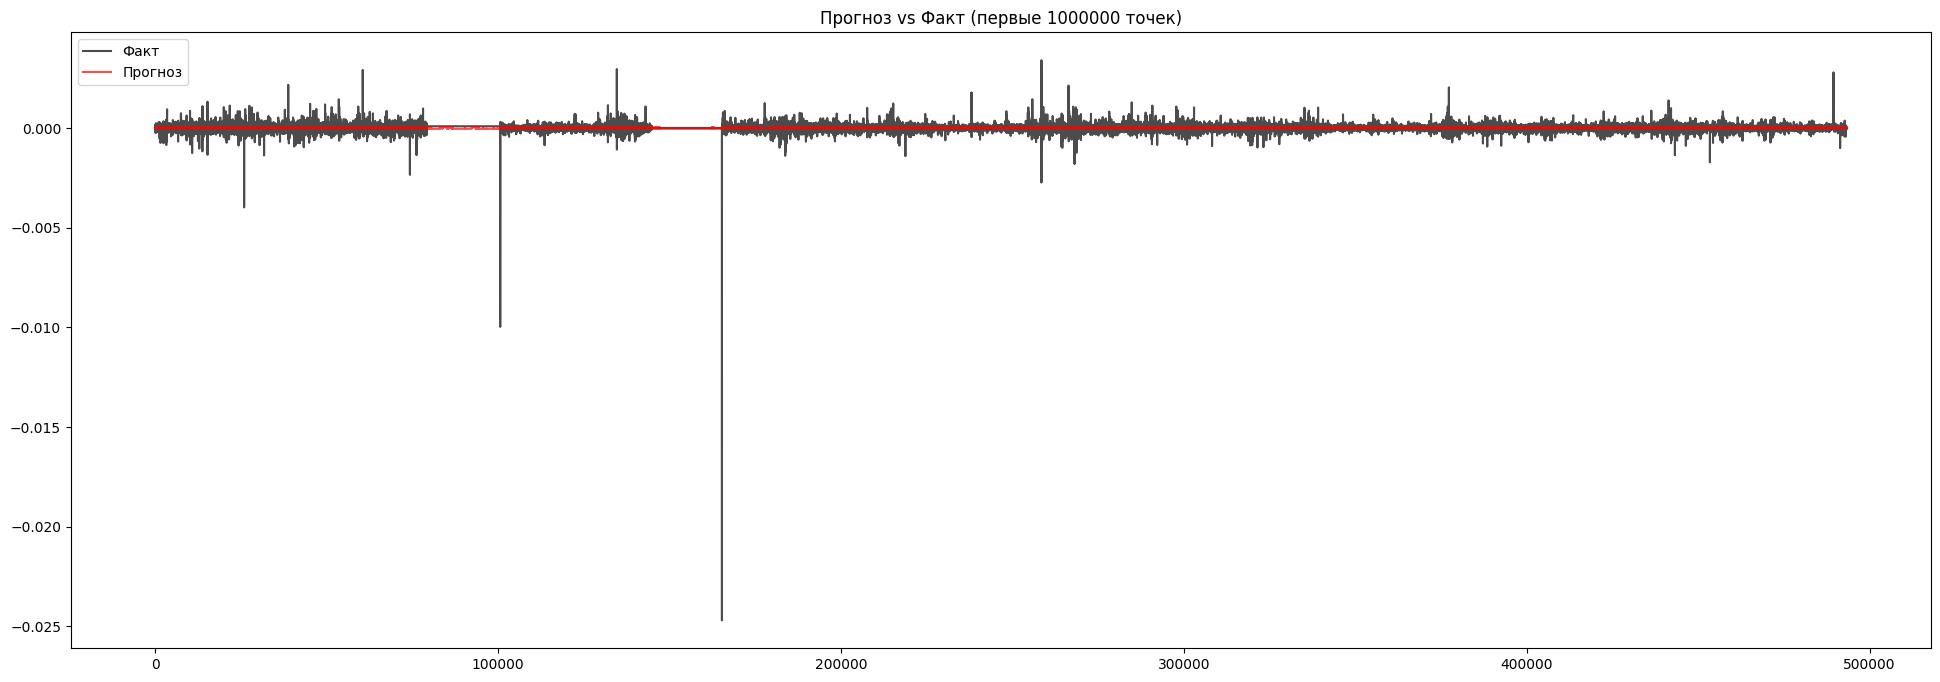

In [6]:
from src.mlcore.evaluation import evaluate_regression_model

y_mid_pred = mid_model.predict(X_test)

evaluate_regression_model(
    y_test=y_mid_test,
    y_pred=y_mid_pred,
    length=1000000,
)

### Обучаем spread model

In [7]:
from src.mlcore.train import train_regression_model

spread_model = train_regression_model(
    X_train=X_train,
    y_train=y_spread_train,
    X_test=X_test,
    y_test=y_spread_test,
    n_estimators=5000,
    objective='reg:squaredlogerror',
    model_name="model_spread",
    max_depth=1,
)

Обучение модели...
[0]	validation_0-rmse:0.00016
[50]	validation_0-rmse:0.00014
[100]	validation_0-rmse:0.00013
[150]	validation_0-rmse:0.00012
[200]	validation_0-rmse:0.00012
[250]	validation_0-rmse:0.00012
[300]	validation_0-rmse:0.00011
[350]	validation_0-rmse:0.00011
[400]	validation_0-rmse:0.00011
[428]	validation_0-rmse:0.00011
Модель сохранена в директорию: models/model_spread.json


MAE                      : 0.000085
RMSE                     : 0.000113
R²                       : 0.228452
MAE / mean|Δ|            : 0.890152
RMSE / RMSE_base         : 0.705632
mean|Δ| (target)         : 0.000095

------------------------------------------------------------
Directional Accuracy     : 0.809469
Target Pos Ratio         : 0.809469
Profit Factor            : 46849628508.830803
Avg Gain (correct)       : 0.000117
Avg Loss (incorrect)     : 0.000000

------------------------------------------------------------
Binomial p-value (vs 50%)     : 0.000000
Directional Acc 95% CI        : (0.8084, 0.8105)
Is Significant (α=5%)         : True

📊 Квантильный анализ (топ-3 квантиля по уверенности):
            quantile  confidence  directional_acc  mean_return  n_samples
 (0.000211, 0.00114]    0.000287         0.998358     0.000275      49322
(0.000164, 0.000211]    0.000181         0.991038     0.000120      49322
(0.000127, 0.000164]    0.000143         0.953710     0.000140    

/root/AlgoTradingSystem_c1/src/mlcore/evaluation.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for q, group in df.groupby('quantile'):


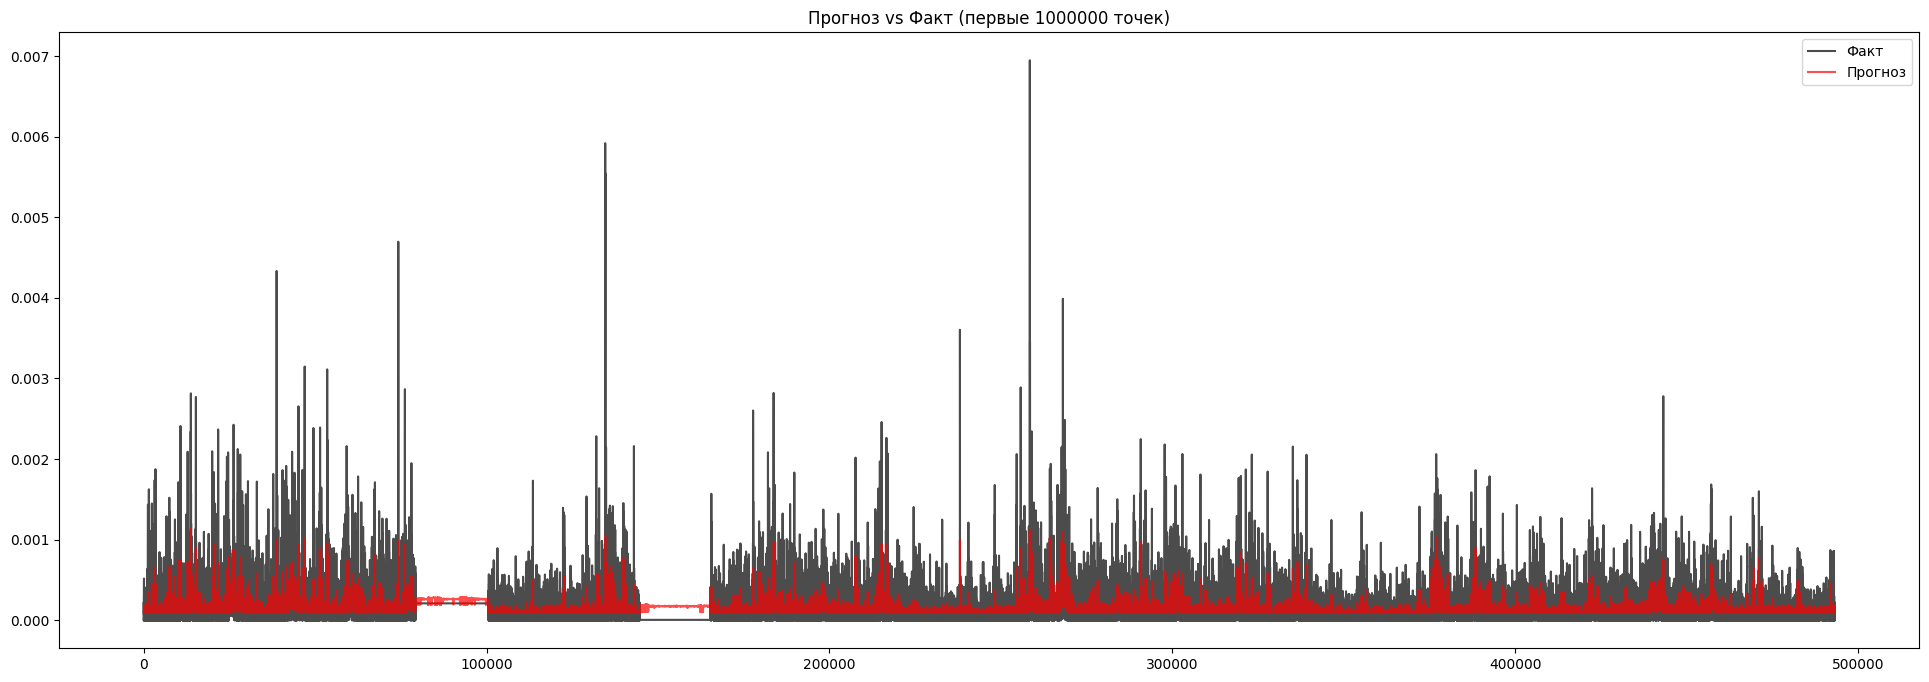

In [8]:
from src.mlcore.evaluation import evaluate_regression_model

y_spread_pred = spread_model.predict(X_test)

evaluate_regression_model(
    y_test=y_spread_test,
    y_pred=y_spread_pred,
    length=1000000,
)